# Importing the dataset

Importing the dataset csv file then creating two copies: main and copy

main: The primary dataset to be used during training <br>
copy: The dataset to be used for experimental preprocessing and visualization

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import (
    StandardScaler, 
    OneHotEncoder, 
    LabelEncoder, 
    OrdinalEncoder,
    TargetEncoder
)

In [45]:
main_dset = pd.read_csv("/home/mikkel/Desktop/ai-projects/machine-learning/ug-ransomware/datasets/final(2).csv")
copy_dset = main_dset.copy()

In [3]:
main_dset

,Time,Protcol,Flag,Family,Clusters,SeddAddress,ExpAddress,BTC,USD,Netflow_Bytes,IPaddress,Threats,Port,Prediction
0,50,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,500,5,A,Bonet,5061,SS
1,40,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,504,8,A,Bonet,5061,SS
2,30,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,508,7,A,Bonet,5061,SS
3,20,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,512,15,A,Bonet,5061,SS
4,57,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,516,9,A,Bonet,5061,SS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149038,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1010,1590,3340,A,Scan,5062,A
149039,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1014,1596,3351,A,Scan,5062,A
149040,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1018,1602,3362,A,Scan,5062,A
149041,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1022,1608,3373,A,Scan,5062,A


In [4]:
copy_dset

,Time,Protcol,Flag,Family,Clusters,SeddAddress,ExpAddress,BTC,USD,Netflow_Bytes,IPaddress,Threats,Port,Prediction
0,50,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,500,5,A,Bonet,5061,SS
1,40,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,504,8,A,Bonet,5061,SS
2,30,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,508,7,A,Bonet,5061,SS
3,20,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,512,15,A,Bonet,5061,SS
4,57,TCP,A,WannaCry,1,1DA11mPS,1BonuSr7,1,516,9,A,Bonet,5061,SS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149038,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1010,1590,3340,A,Scan,5062,A
149039,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1014,1596,3351,A,Scan,5062,A
149040,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1018,1602,3362,A,Scan,5062,A
149041,33,UDP,AP,TowerWeb,3,1AEoiHYZ,1SYSTEMQ,1022,1608,3373,A,Scan,5062,A


# Visualizing and understanding the dataset's information

In [5]:
categorical_feats = ["Protcol", "Flag", "Family", "Threats", "SeddAddress", "ExpAddress", "IPaddress"]
numerical_feats = ["Time", "Clusters", "BTC", "USD", "Netflow_Bytes", "Port"]

# Getting the basic information
print(f"Dataset's info: \n{copy_dset.info()}\n\n")

<class 'pandas.DataFrame'>
RangeIndex: 149043 entries, 0 to 149042
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Time           149043 non-null  int64
 1   Protcol        149043 non-null  str  
 2   Flag           149043 non-null  str  
 3   Family         149043 non-null  str  
 4   Clusters       149043 non-null  int64
 5   SeddAddress    149043 non-null  str  
 6   ExpAddress     149043 non-null  str  
 7   BTC            149043 non-null  int64
 8   USD            149043 non-null  int64
 9   Netflow_Bytes  149043 non-null  int64
 10  IPaddress      149043 non-null  str  
 11  Threats        149043 non-null  str  
 12  Port           149043 non-null  int64
 13  Prediction     149043 non-null  str  
dtypes: int64(6), str(8)
memory usage: 15.9 MB
Dataset's info: 
None




In [6]:
copy_dset.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,149043.0,21.466979,15.883598,-10.0,8.0,19.0,32.0,96.0
Clusters,149043.0,2.349295,2.828759,1.0,1.0,1.0,2.0,12.0
BTC,149043.0,30.554605,101.447102,1.0,8.0,13.0,22.0,1980.0
USD,149043.0,14863.441114,26849.434659,1.0,512.0,4321.0,18454.0,126379.0
Netflow_Bytes,149043.0,2021.278651,2271.420987,1.0,353.0,1031.0,3188.0,12360.0
Port,149043.0,5063.949967,2.696011,5061.0,5062.0,5062.0,5066.0,5068.0


In [7]:
copy_dset.isna().sum()

Time             0
Protcol          0
Flag             0
Family           0
Clusters         0
SeddAddress      0
ExpAddress       0
BTC              0
USD              0
Netflow_Bytes    0
IPaddress        0
Threats          0
Port             0
Prediction       0
dtype: int64

In [8]:
copy_dset.isnull().sum()

Time             0
Protcol          0
Flag             0
Family           0
Clusters         0
SeddAddress      0
ExpAddress       0
BTC              0
USD              0
Netflow_Bytes    0
IPaddress        0
Threats          0
Port             0
Prediction       0
dtype: int64

In [9]:
copy_dset.duplicated().sum()

np.int64(0)

In [10]:
# Getting the categorical feature's information
for cat_feat in categorical_feats:
    label, label_count = np.unique(copy_dset[cat_feat], return_counts=True)
    print(f"Feature: {cat_feat} | \nUnique features: {label} | \nUnique feature counts: {label_count}\n\n")

Feature: Protcol | 
Unique features: ['ICMP' 'TCP' 'UDP'] | 
Unique feature counts: [37534 68115 43394]


Feature: Flag | 
Unique features: ['A' 'AF' 'AP' 'APRSF' 'APS' 'APSF' 'ARF' 'ASF' 'R'] | 
Unique feature counts: [ 1638 53942  9883  5286 25177 16047 11685  7836 17549]


Feature: Family | 
Unique features: ['APT' 'CryptXXX' 'CryptoLocker' 'CryptoLocker2015' 'Cryptohitman'
 'DMALocker' 'EDA2' 'Flyper' 'Globe' 'Globev3' 'JigSaw' 'Locky'
 'NoobCrypt' 'Razy' 'SamSam' 'TowerWeb' 'WannaCry'] | 
Unique feature counts: [ 9730  9335   788   150  4134 11360  6054 12014  7373    73 13712 25062
  1248  7862 19657  4381 16110]


Feature: Threats | 
Unique features: ['Blacklist' 'Bonet' 'DoS' 'NerisBonet' 'Port Scanning' 'SSH' 'Scan'
 'Spam' 'UDP Scan'] | 
Unique feature counts: [16356 16523 12731  6241 15910 24726 12568 23207 20781]


Feature: SeddAddress | 
Unique features: ['17dcMo4V' '1AEoiHYZ' '1DA11mPS' '1GZkujBR' '1KZKcvx4' '1NKi9AK5'] | 
Unique feature counts: [40201  3096 58453 31569  

# Viewing correlation

### Viewing the correlation of the numerical features

<Axes: >

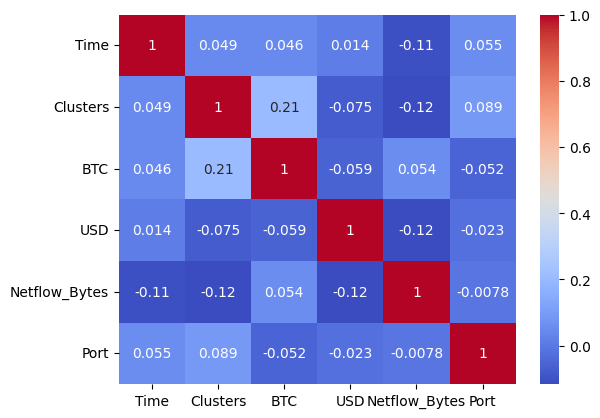

In [11]:
numerical_features = copy_dset.select_dtypes("int64")
num_feat_corr = numerical_features.corr()
sns.heatmap(num_feat_corr, annot=True, cmap="coolwarm")

### Viewing the correlation of categorical features

<Axes: >

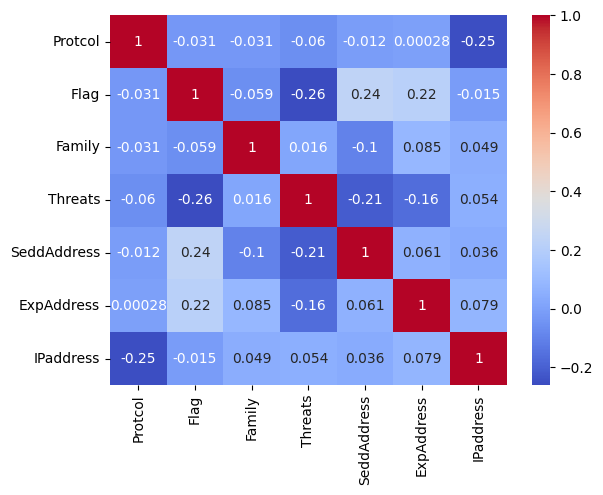

In [12]:
y_col = copy_dset["Prediction"]
temp_oe = OrdinalEncoder().set_output(transform="pandas")
temp_le_dset = temp_oe.fit_transform(copy_dset[categorical_feats])
sns.heatmap(temp_le_dset.corr(), annot=True, cmap="coolwarm")

### Visualizing the correlation between feature and target

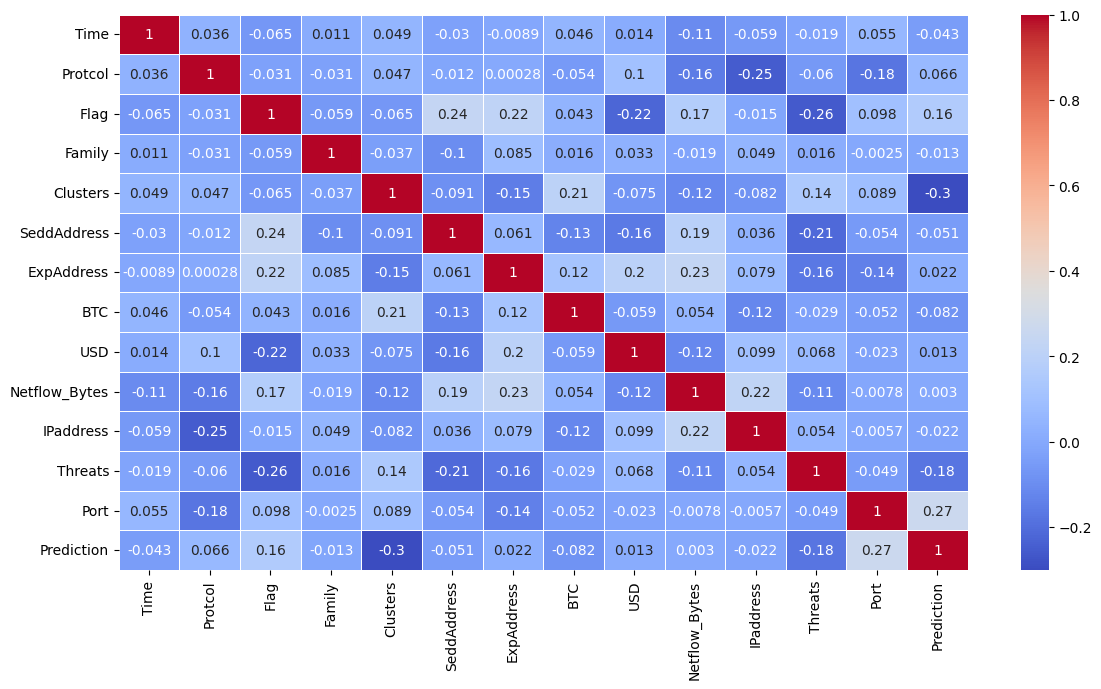

In [13]:
temp_le = LabelEncoder()

plt.figure(figsize=(12, 7))

copy_dset_two = copy_dset.copy()
copy_dset_two[categorical_feats] = temp_oe.fit_transform(copy_dset_two[categorical_feats])
copy_dset_two["Prediction"] = temp_le.fit_transform(copy_dset_two["Prediction"])

ax = sns.heatmap(
    copy_dset_two.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.tight_layout()
plt.show()


# Visualizing the numerical features of the dataset

Visualizing the distributions of each numerical feature

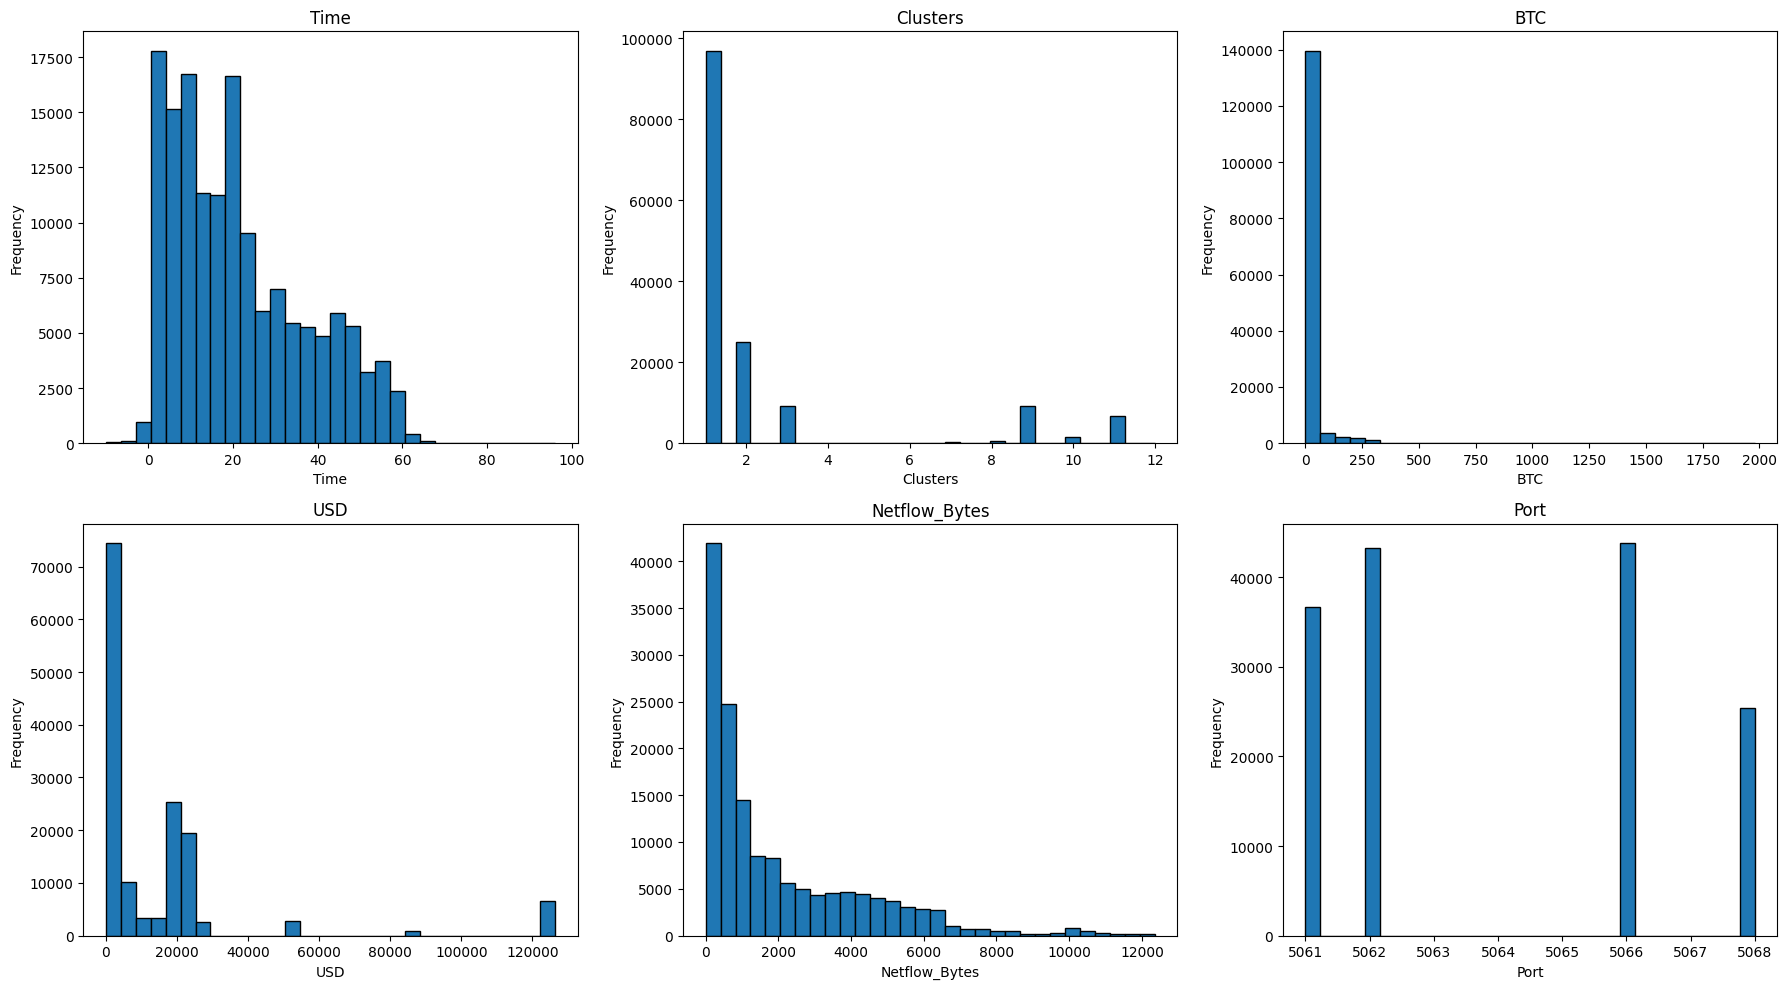

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(numerical_feats):
    col = feat if feat in copy_dset.columns else "Netflow_Bytes" if feat == "Netflow_bytes" else feat
    axes[i].hist(copy_dset[col], bins=30, edgecolor="black")
    axes[i].set_title(feat)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Frequency")

for j in range(len(numerical_feats), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

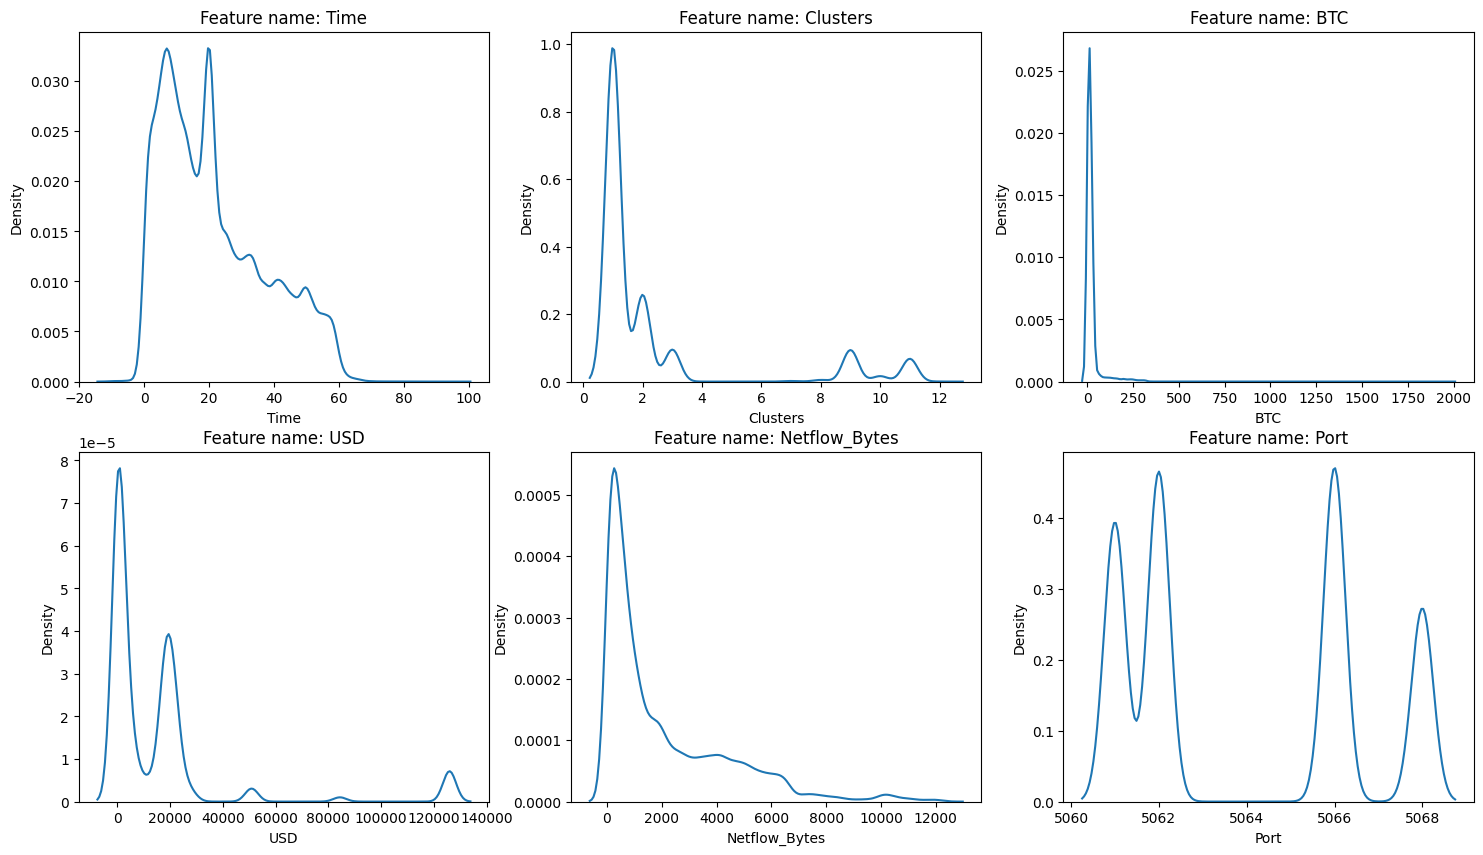

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.flatten()

for i, feature in enumerate(numerical_feats):
    sns.kdeplot(copy_dset, x=feature, ax=ax[i])
    ax[i].set_title(f"Feature name: {feature}")

# Visualizing the categorical features of the dataset

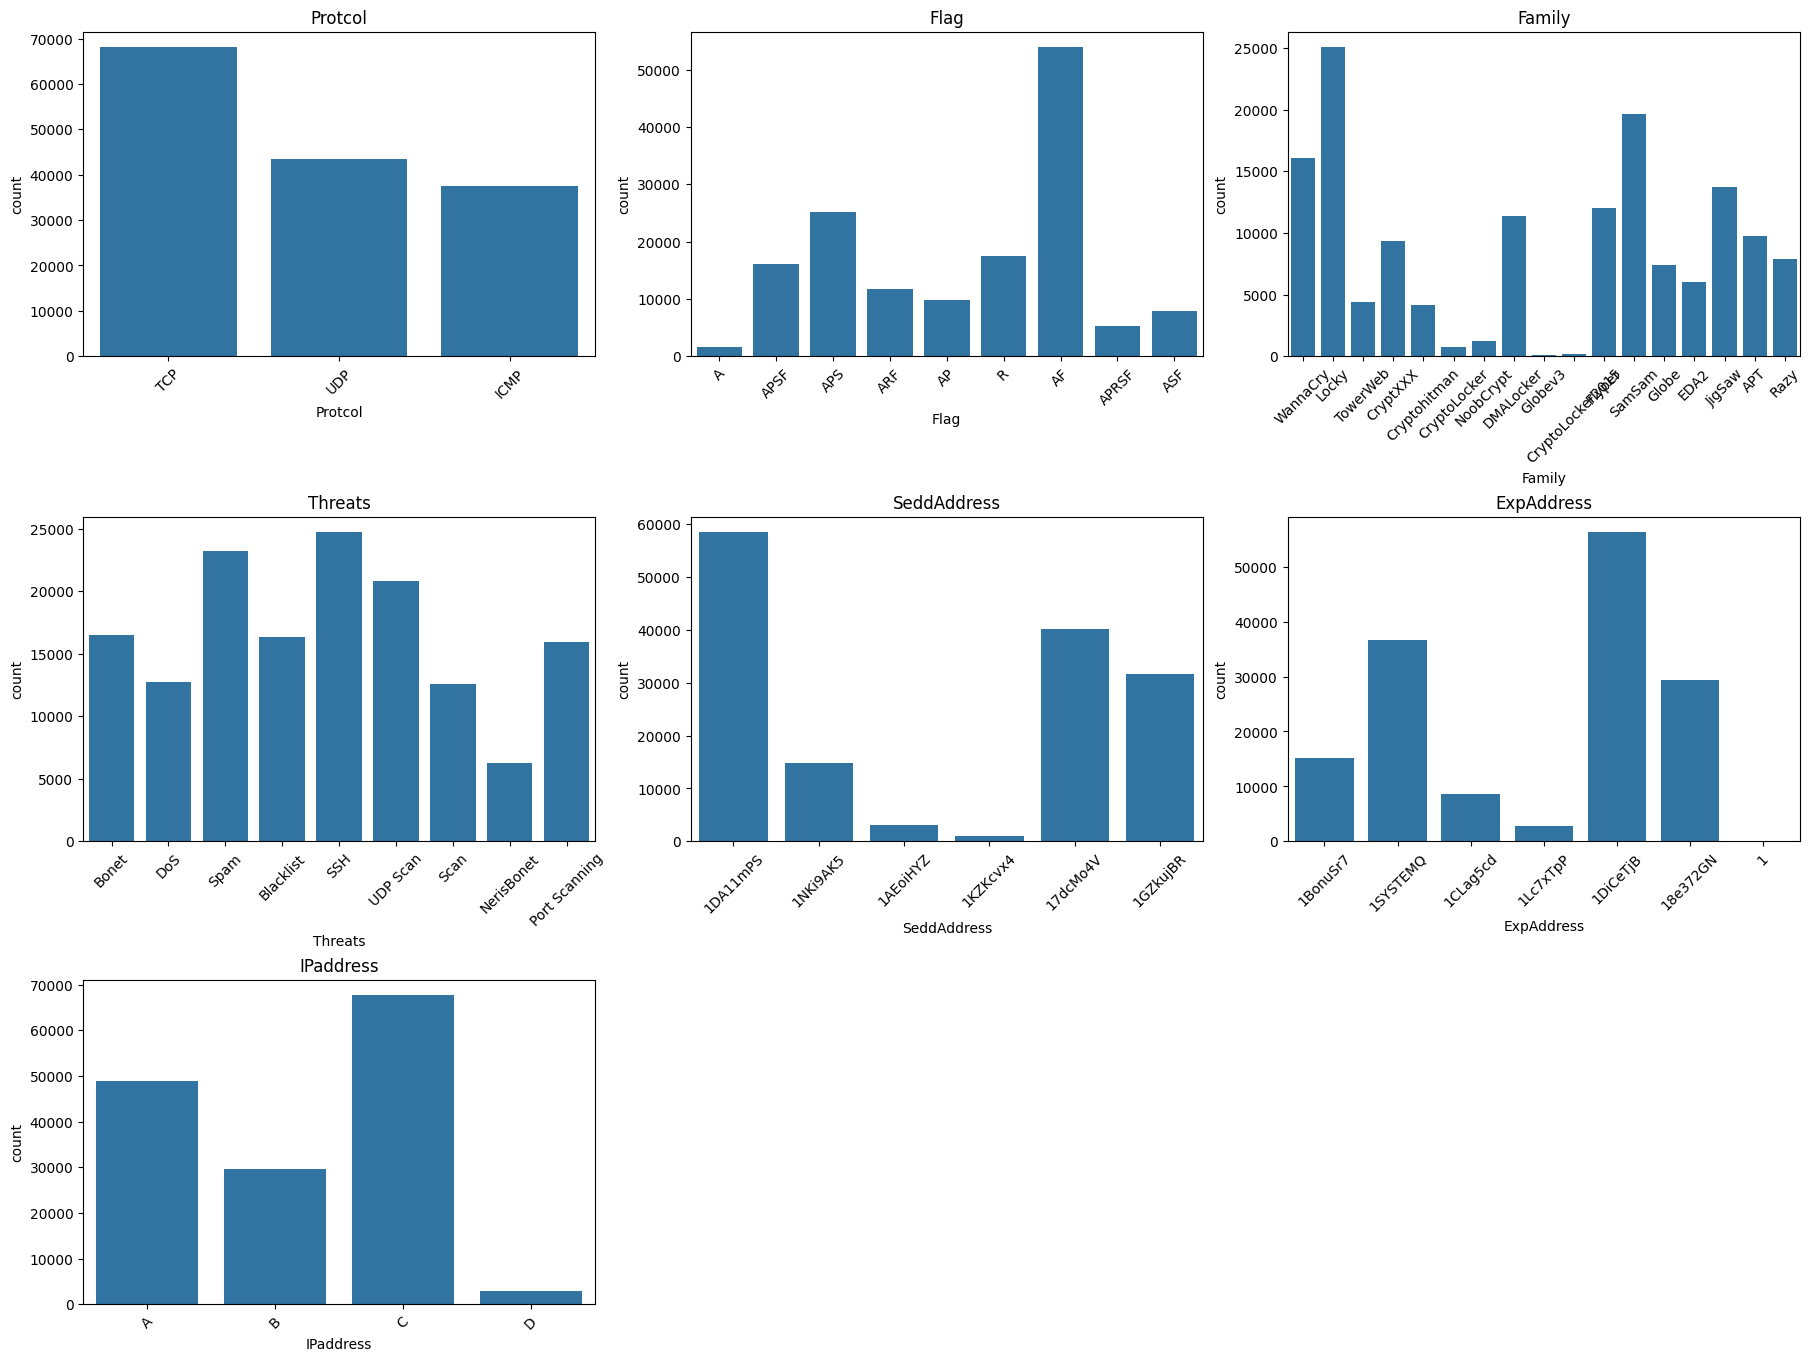

In [16]:
# Count plots for categorical features (7 plots total)
extra_feat = "Prediction"
plot_feats = categorical_feats + [extra_feat] if extra_feat in copy_dset.columns else categorical_feats
n_plots = min(7, len(plot_feats))

n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), constrained_layout=True)
axes = axes.ravel()

for i, feat in enumerate(plot_feats[:n_plots]):
    sns.countplot(data=copy_dset, x=feat, ax=axes[i])
    axes[i].set_title(feat)
    axes[i].tick_params(axis="x", rotation=45)

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.show()

<Axes: xlabel='count', ylabel='Prediction'>

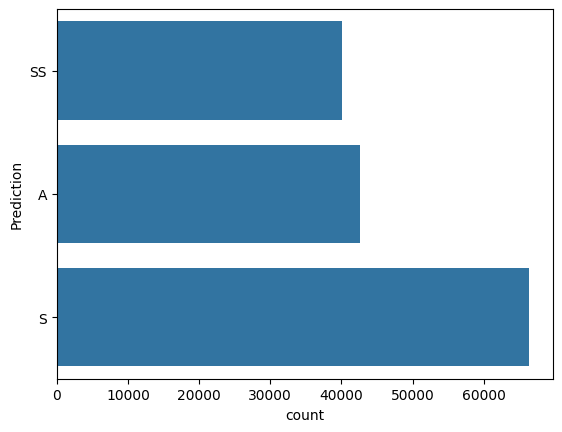

In [17]:
sns.countplot(copy_dset["Prediction"])

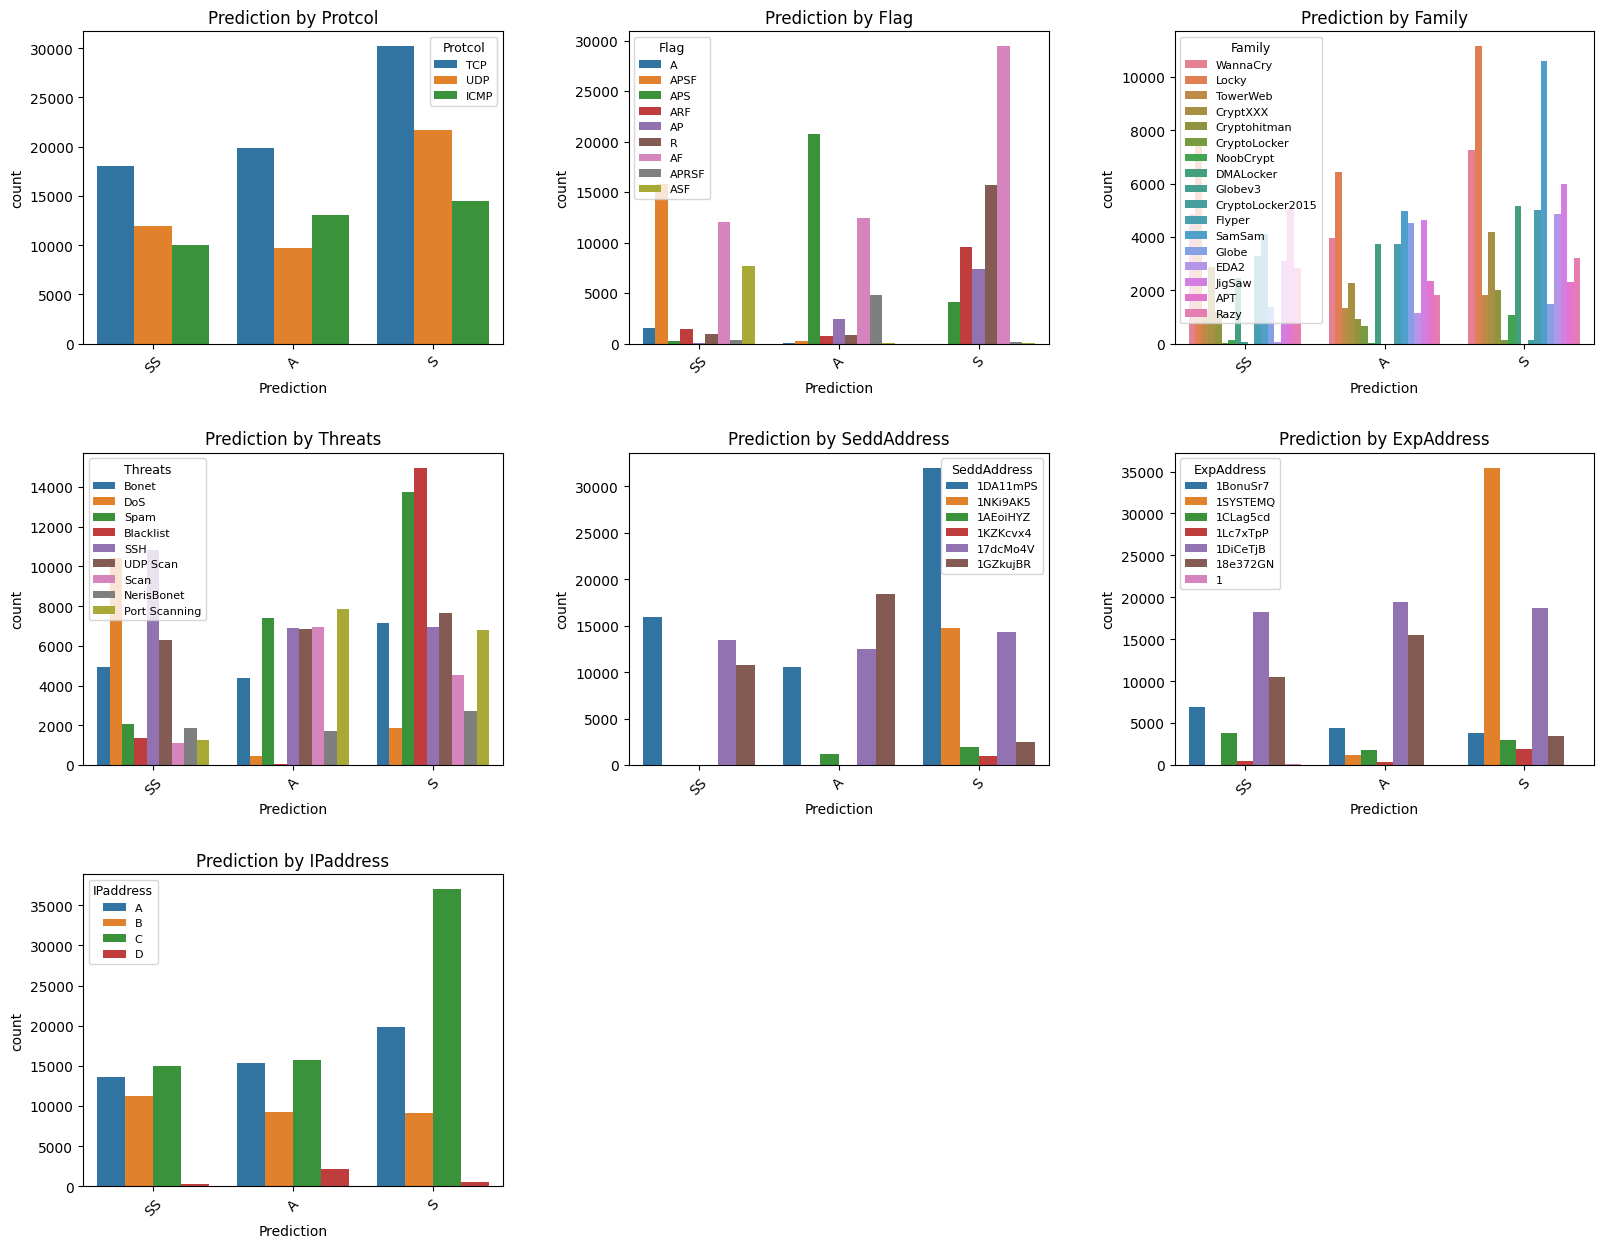

In [18]:
# Count plots of Prediction with each categorical feature as hue
x_col = "Prediction" if "Prediction" in copy_dset.columns else categorical_feats[0]

n_cols = 3
n_rows = (len(categorical_feats) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 5 * n_rows))
axes = axes.ravel()

for i, hue_feat in enumerate(categorical_feats):
    sns.countplot(data=copy_dset, x=x_col, hue=hue_feat, ax=axes[i])
    axes[i].set_title(f"{x_col} by {hue_feat}")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(title=hue_feat, fontsize=8, title_fontsize=9)

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.subplots_adjust(wspace=0.3, hspace=0.35)
plt.show()

# Doing experimental preprocessing on copy_dset

In [19]:
categorical_feats = ["Protcol", "Flag", "Family", "Threats", "SeddAddress", "ExpAddress", "IPaddress"]
numerical_feats = ["Time", "Clusters", "BTC", "USD", "Netflow_bytes", "Port"]

In [46]:
columns_to_remove = [
    "SeddAddress", 
    "ExpAddress", 
    "Family", 
    "BTC", 
    "USD", 
    "IPaddress", 
    "Port", 
    "Threats",
    "Clusters"
]

copy_dset = copy_dset.drop(columns_to_remove, axis=1)

In [49]:
X = copy_dset.iloc[:, :-1]
Y = copy_dset.iloc[:, -1]

### Standardizing the numerical features

This is done to ensure that no other numerical feature dominates one another <br>
and to bring a mean of 0 and a standard deviation of 1.

In [52]:
stan_scaler = StandardScaler()
X[["Time", "Netflow_Bytes"]] = stan_scaler.fit_transform(X[["Time", "Netflow_Bytes"]])

In [37]:
copy_dset

,Time,Protcol,Flag,Netflow_Bytes,Prediction
0,1.796389,TCP,A,-0.887676,SS
1,1.166806,TCP,A,-0.886355,SS
2,0.537224,TCP,A,-0.886795,SS
3,-0.092358,TCP,A,-0.883273,SS
4,2.237096,TCP,A,-0.885915,SS
...,...,...,...,...,...
149038,0.726099,UDP,AP,0.580573,A
149039,0.726099,UDP,AP,0.585416,A
149040,0.726099,UDP,AP,0.590259,A
149041,0.726099,UDP,AP,0.595101,A


### TargetEncoding

Due to the large amount of unique features in the Flag feature, <br>
I have decided to use TargetEncoding, it encodes that particular categorical variable <br>
with the mean of the corresponding target value

In [24]:
np.unique(copy_dset[["Protcol"]], return_counts=True)

(array(['ICMP', 'TCP', 'UDP'], dtype=object), array([37534, 68115, 43394]))

In [25]:
np.unique(copy_dset[["Flag"]], return_counts=True)

(array(['A', 'AF', 'AP', 'APRSF', 'APS', 'APSF', 'ARF', 'ASF', 'R'],
       dtype=object),
 array([ 1638, 53942,  9883,  5286, 25177, 16047, 11685,  7836, 17549]))

In [54]:
protcol_ohe = OneHotEncoder()
flag_te = TargetEncoder(target_type="multiclass")

encoded_protocols = protcol_ohe.fit_transform(X[["Protcol"]])
encoded_flags = flag_te.fit_transform(X[["Flag"]], Y)

temp_prot_df = pd.DataFrame(encoded_protocols.toarray(), columns=protcol_ohe.get_feature_names_out())
temp_flag_df = pd.DataFrame(encoded_flags, columns=flag_te.get_feature_names_out())

In [55]:
temp_flag_df

,Flag_A,Flag_S,Flag_SS
0,0.059461,0.000000,0.940439
1,0.061969,0.000000,0.937928
2,0.061587,0.000000,0.938310
3,0.061969,0.000000,0.937928
4,0.061587,0.000000,0.938310
...,...,...,...
149038,0.247444,0.747727,0.004805
149039,0.249300,0.745935,0.004741
149040,0.249300,0.745935,0.004741
149041,0.250067,0.744985,0.004924


In [56]:
temp_prot_df

,Protcol_ICMP,Protcol_TCP,Protcol_UDP
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
149038,0.0,0.0,1.0
149039,0.0,0.0,1.0
149040,0.0,0.0,1.0
149041,0.0,0.0,1.0


In [57]:
X

,Time,Protcol,Flag,Netflow_Bytes
0,1.796389,TCP,A,-0.887676
1,1.166806,TCP,A,-0.886355
2,0.537224,TCP,A,-0.886795
3,-0.092358,TCP,A,-0.883273
4,2.237096,TCP,A,-0.885915
...,...,...,...,...
149038,0.726099,UDP,AP,0.580573
149039,0.726099,UDP,AP,0.585416
149040,0.726099,UDP,AP,0.590259
149041,0.726099,UDP,AP,0.595101


In [61]:
for column, dataframe in zip(["Protcol", "Flag"], [temp_prot_df, temp_flag_df]):
    X = pd.concat([
        X.drop([column], axis=1),
        dataframe
    ],
    axis=1
    )


In [62]:
X

,Time,Netflow_Bytes,Protcol_ICMP,Protcol_TCP,Protcol_UDP,Flag_A,Flag_S,Flag_SS
0,1.796389,-0.887676,0.0,1.0,0.0,0.059461,0.000000,0.940439
1,1.166806,-0.886355,0.0,1.0,0.0,0.061969,0.000000,0.937928
2,0.537224,-0.886795,0.0,1.0,0.0,0.061587,0.000000,0.938310
3,-0.092358,-0.883273,0.0,1.0,0.0,0.061969,0.000000,0.937928
4,2.237096,-0.885915,0.0,1.0,0.0,0.061587,0.000000,0.938310
...,...,...,...,...,...,...,...,...
149038,0.726099,0.580573,0.0,0.0,1.0,0.247444,0.747727,0.004805
149039,0.726099,0.585416,0.0,0.0,1.0,0.249300,0.745935,0.004741
149040,0.726099,0.590259,0.0,0.0,1.0,0.249300,0.745935,0.004741
149041,0.726099,0.595101,0.0,0.0,1.0,0.250067,0.744985,0.004924


### LabelEncoding the prediction column